In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("TF version:", tf.__version__)
print("GPUs verfügbar:", tf.config.list_physical_devices('GPU'))

# ── Load preprocessed data from Notebook 02 ──────────────────
DATA_DIR = Path("../data/processed")

X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_test  = np.load(DATA_DIR / "X_test.npy")
y_test  = np.load(DATA_DIR / "y_test.npy")
groups_test = np.load(DATA_DIR / "groups_test.npy")

print(f"groups_test: {groups_test.shape}, unique files: {len(np.unique(groups_test))}")
print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

# Conv layers expect a channel dimension: (samples, height, width, channels)
X_train = X_train[..., np.newaxis]   # (16340, 128, 32, 1)
X_test  = X_test[..., np.newaxis]

print(f"\nAfter reshape:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

TF version: 2.21.0
GPUs verfügbar: []
groups_test: (10602,), unique files: 558

X_train: (16340, 128, 32)
X_test:  (10602, 128, 32)

After reshape:
X_train: (16340, 128, 32, 1)
X_test:  (10602, 128, 32, 1)


In [58]:
# Per File-Aggregation

file_ids = np.unique(groups_test)

agg_mean, agg_max, agg_p90, file_labels = [], [], [], []

for fid in file_ids:
    mask = groups_test == fid                    # alle Windows dieser Datei
    errs = reconstruction_errors[mask]

    agg_mean.append(errs.mean())
    agg_max.append(errs.max())
    agg_p90.append(np.percentile(errs, 90))

    # Label der Datei (alle Windows haben dasselbe → nimm das erste)
    file_labels.append(y_test[mask][0])

agg_mean   = np.array(agg_mean)
agg_max    = np.array(agg_max)
agg_p90    = np.array(agg_p90)
file_labels = np.array(file_labels)

print(f"Aggregated to {len(file_labels)} files")
print(f"  normal:   {(file_labels == 0).sum()}")   
print(f"  abnormal: {(file_labels == 1).sum()}")   

Aggregated to 558 files
  normal:   151
  abnormal: 407


In [59]:
# smaller bottleneck = more prioritization (4 instead of 8 filters)
# added Conv-Layer prior to first pooling layer --> more detailed frequencies before they are smoothed away
# batch normalization --> stabilsed training and recognition of fine patterns

def build_autoencoder_v2(input_shape=(128, 32, 1)):
    inputs = keras.Input(shape=input_shape)

    # -- Encoder 
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)   # extra Layer
    x = layers.MaxPooling2D((2, 2), padding="same")(x)        # → 64×16×32

    x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)        # → 32×8×16

    x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same")(x)  # → 16×4×8

    # Tighter Bottleneck via Dense-Squeeze
    flat = layers.Flatten()(encoded)
    bottleneck = layers.Dense(64, activation="relu", name="bottleneck")(flat)  # erzwungene Kompression!
    x = layers.Dense(16 * 4 * 8, activation="relu")(bottleneck)
    x = layers.Reshape((16, 4, 8))(x)

    # -- Decoder 
    x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)

    outputs = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

    autoencoder = keras.Model(inputs, outputs, name="conv_autoencoder_v2")
    return autoencoder


autoencoder_v2 = build_autoencoder_v2()
autoencoder_v2.summary()

Model: "conv_autoencoder_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 32, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 128, 32, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 128, 32, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 128, 32, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 64, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 32, 8, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 8, 8)       │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 8, 8)       │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 4, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 16, 4, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_12             │ (None, 32, 8, 8)       │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 8, 8)       │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 64, 16, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 128, 32, 32)    │         4,640 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 128, 32, 32)    │         9,24

 Total params: 97,713 (381.69 KB)

 Trainable params: 97,553 (381.07 KB)

 Non-trainable params: 160 (640.00 B)

In [60]:
# Cell 3 - Compile and train model based on new architecture

autoencoder_v2.compile(optimizer="adam", loss="mse")

early_stop_v2 = EarlyStopping(
    monitor="val_loss",
    patience=7,          
    restore_best_weights=True
)

history_v2 = autoencoder_v2.fit(
    X_train, X_train,
    epochs=60,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_v2],
    verbose=1
)

Epoch 1/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 63s 267ms/step - loss: 0.0042 - val_loss: 0.0606
Epoch 2/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 64s 278ms/step - loss: 0.0018 - val_loss: 0.0307
Epoch 3/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 64s 280ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 4/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 63s 272ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 5/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 63s 274ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 6/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 63s 275ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 7/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 64s 277ms/step - loss: 0.0015 - val_loss: 0.0023
Epoch 8/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 63s 272ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 9/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 63s 273ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 10/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 63s 274ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 11/60
230/230 ━━━━━━━━━━━━━━━━━━━━ 63s 274ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 12/60
230/230

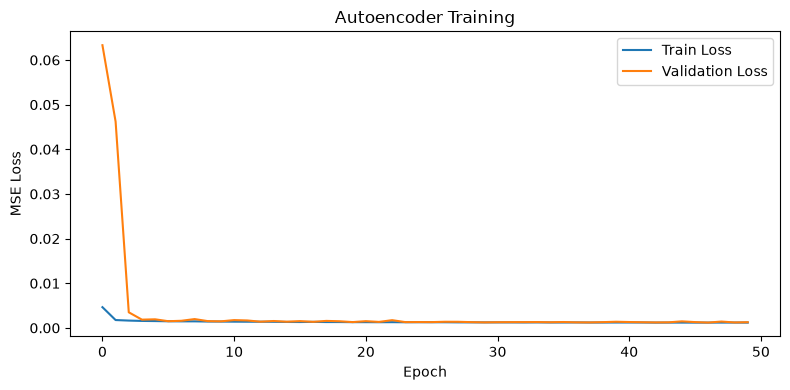

In [61]:
# Cell 5 - Trainings-Verlauf visualisieren

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training")
plt.legend()
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

In [62]:
# Cell 6 - Reconstruction Error on TEST-Set

X_test_pred = autoencoder_v2.predict(X_test, batch_size=64, verbose=1)

# Mean Squared Error PRO SAMPLE (nicht über den ganzen Batch gemittelt!)
reconstruction_errors = np.mean(
    np.square(X_test - X_test_pred), axis=(1, 2, 3)
)

print(f"Reconstruction errors shape: {reconstruction_errors.shape}")
print(f"Min: {reconstruction_errors.min():.5f}")
print(f"Max: {reconstruction_errors.max():.5f}")

166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step
Reconstruction errors shape: (10602,)
Min: 0.00087
Max: 0.00611


In [63]:
from sklearn.metrics import roc_auc_score

auc_window = roc_auc_score(y_test, reconstruction_errors)

auc_mean = roc_auc_score(file_labels, agg_mean)
auc_max = roc_auc_score(file_labels, agg_max)
auc_p90 = roc_auc_score(file_labels, agg_p90)

print(f"AUC window-wise (baseline): {auc_window:.4f}")
print(f"AUC per-file MEAN: {auc_mean:.4f}")
print(f"AUC per-file MAX: {auc_max:.4f}")
print(f"AUC per-file P90: {auc_p90:.4f}")

AUC window-wise (baseline): 0.7093
AUC per-file MEAN: 0.6803
AUC per-file MAX: 0.6548
AUC per-file P90: 0.6677


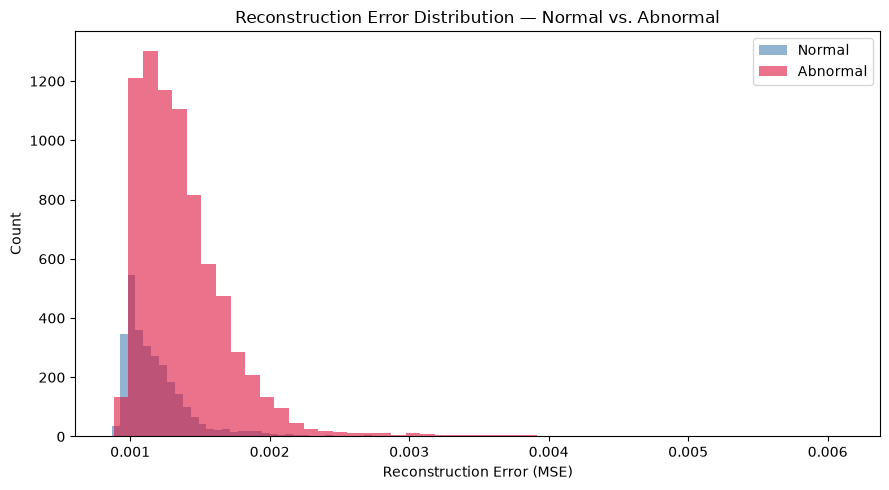

Normal   — mean: 0.00120, std: 0.00030
Abnormal — mean: 0.00138, std: 0.00038


In [64]:
# Cell 7 - Error Distribution: normal vs. abnormal

errors_normal   = reconstruction_errors[y_test == 0]
errors_abnormal = reconstruction_errors[y_test == 1]

plt.figure(figsize=(9, 5))
plt.hist(errors_normal, bins=50, alpha=0.6, label="Normal", color="steelblue")
plt.hist(errors_abnormal, bins=50, alpha=0.6, label="Abnormal", color="crimson")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution — Normal vs. Abnormal")
plt.legend()
plt.tight_layout()
plt.savefig("reconstruction_error_distribution.png", dpi=150)
plt.show()

print(f"Normal   — mean: {errors_normal.mean():.5f}, std: {errors_normal.std():.5f}")
print(f"Abnormal — mean: {errors_abnormal.mean():.5f}, std: {errors_abnormal.std():.5f}")

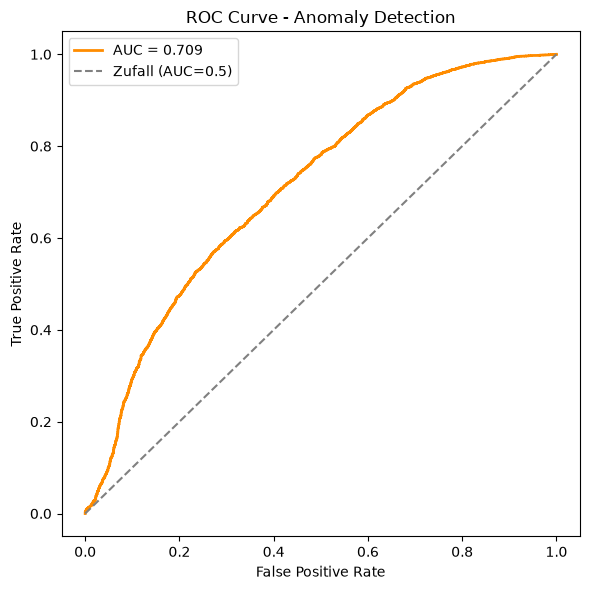

AUC Score: 0.7093


In [65]:
# Cell 8 - ROC Curve and AUC Score

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, threshold = roc_curve(y_test, reconstruction_errors)
auc_score = roc_auc_score(y_test, reconstruction_errors)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}", color="darkorange", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Zufall (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Anomaly Detection")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

print(f"AUC Score: {auc_score:.4f}")

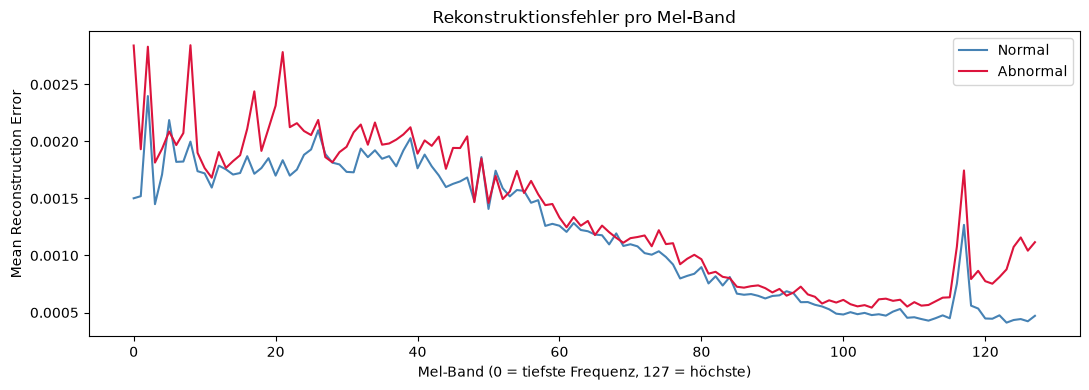

Top-10 Bänder mit größtem Unterschied (abnormal − normal):
[np.int64(0), np.int64(8), np.int64(17), np.int64(20), np.int64(21), np.int64(117), np.int64(124), np.int64(125), np.int64(126), np.int64(127)]


In [66]:
# Reconstruction Error PRO MEL-BAND
 
err_per_band = np.mean(np.square(X_test - X_test_pred), axis=(2, 3))  # shape: (n_samples, 128)

band_err_normal   = err_per_band[y_test == 0].mean(axis=0)   # (128,)
band_err_abnormal = err_per_band[y_test == 1].mean(axis=0)   # (128,)

plt.figure(figsize=(11, 4))
plt.plot(band_err_normal,   label="Normal",   color="steelblue")
plt.plot(band_err_abnormal, label="Abnormal", color="crimson")
plt.xlabel("Mel-Band (0 = tiefste Frequenz, 127 = höchste)")
plt.ylabel("Mean Reconstruction Error")
plt.title("Rekonstruktionsfehler pro Mel-Band")
plt.legend()
plt.tight_layout()
plt.savefig("error_per_band.png", dpi=150)
plt.show()

diff = band_err_abnormal - band_err_normal
top_bands = np.argsort(diff)[::-1][:10]
print("Top-10 Bänder mit größtem Unterschied (abnormal − normal):")
print(sorted(top_bands))

In [67]:
# weighted AZC-SCore without Data-Leakage

def evaluate_one_split(seed):
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(file_ids)
    split = len(shuffled) // 2
    calib_files = set(shuffled[:split].tolist())
    eval_files  = set(shuffled[split:].tolist())

    calib_mask = np.array([g in calib_files for g in groups_test])
    eval_mask  = np.array([g in eval_files  for g in groups_test])

    yc = y_test[calib_mask]
    band_n = err_per_band[calib_mask][yc == 0].mean(axis=0)
    band_a = err_per_band[calib_mask][yc == 1].mean(axis=0)
    w = np.clip(band_a - band_n, 0, None)

    if w.sum() == 0:          # degenerierter Split
        return None
    w = w / w.sum()

    we = err_per_band @ w
    auc_win = roc_auc_score(y_test[eval_mask], we[eval_mask])

    agg, lab = [], []
    for fid in eval_files:
        m = groups_test == fid
        agg.append(we[m].mean())
        lab.append(file_label[fid])
    auc_mean = roc_auc_score(np.array(lab), np.array(agg))
    return auc_win, auc_mean


results_win, results_mean, degenerate = [], [], 0
for seed in range(50):                 
    res = evaluate_one_split(seed)
    if res is None:
        degenerate += 1
        continue
    results_win.append(res[0])
    results_mean.append(res[1])

results_win  = np.array(results_win)
results_mean = np.array(results_mean)

print(f"Gültige Splits: {len(results_mean)} / 50  (degeneriert: {degenerate})\n")
print(f"AUC window-wise:   {results_win.mean():.4f} ± {results_win.std():.4f}"
      f"   [min {results_win.min():.4f}, max {results_win.max():.4f}]")
print(f"AUC per-file MEAN: {results_mean.mean():.4f} ± {results_mean.std():.4f}"
      f"   [min {results_mean.min():.4f}, max {results_mean.max():.4f}]")

Gültige Splits: 50 / 50  (degeneriert: 0)

AUC window-wise:   0.8077 ± 0.0295   [min 0.7569, max 0.8720]
AUC per-file MEAN: 0.8300 ± 0.0333   [min 0.7666, max 0.8990]
